In [133]:
import os
import json
from pydantic import BaseModel
from typing import Literal, Optional
from langchain_anthropic import ChatAnthropic
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import PydanticOutputParser
from langchain_core.runnables import RunnableParallel

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.path import Path
from matplotlib.patches import PathPatch

from dotenv import load_dotenv

load_dotenv()

True

## Loading the models answers

In [134]:
df_list = []

for _json in os.listdir("./results"):

    df_list.append(pd.read_json(f"./results/{_json}"))

results_df = pd.concat(df_list, ignore_index=True)

answers_df = results_df.pivot_table(
    index=["_id", "question"],
    columns="model_name",
    values=["model_answer"], #["model_answer", "latency_seconds"],
    aggfunc="first"
)

answers_df.columns = [model for field, model in answers_df.columns]
answers_df = answers_df.reset_index()

latency_df = results_df.pivot_table(
    index=["_id", "question"],
    columns="model_name",
    values=["latency_seconds"], #["model_answer", "latency_seconds"],
    aggfunc="first"
)

latency_df.columns = [model for field, model in latency_df.columns]
latency_df = latency_df.reset_index()

In [135]:
df_list = []

for _json in os.listdir("./contest"):

    with open(f"./contest/{_json}", "r", encoding="utf-8") as f:

        df_list.append(json.load(f))

contest_df = pd.DataFrame(df_list).sort_values("_id")

In [136]:
scores = contest_df[["gemma3:1b", "gemma3:4b", "llama3.2:1b", "llama3.2:3b"]].sum()/300

scores

gemma3:1b      0.366667
gemma3:4b      0.590000
llama3.2:1b    0.326667
llama3.2:3b    0.580000
dtype: float64

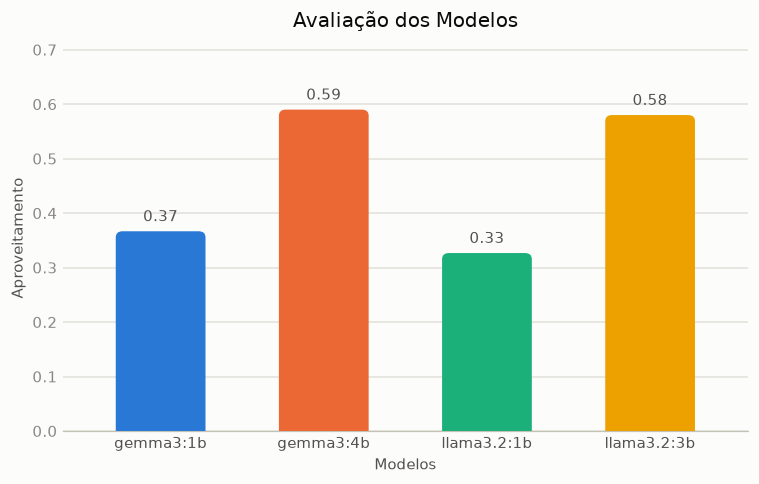

In [142]:
# Fixed categorical order (identity, not ranked by value) — first 4 slots of the
# validated palette, adjacent-pair colorblind-safe for bar charts.
MODEL_COLORS = {
    "gemma3:1b": "#2a78d6",     # slot 1 — blue
    "gemma3:4b": "#eb6834",     # slot 2 — orange
    "llama3.2:1b": "#1baf7a",   # slot 3 — aqua
    "llama3.2:3b": "#eda100",   # slot 4 — yellow
}

def _top_rounded_bar(ax, x_center, height, width, radius_px):
    """A bar path rounded at the top, square at the baseline — matplotlib's
    built-in bar/FancyBboxPatch have no partial-corner rounding, so this
    walks an explicit Path. radius_px is converted to data units separately
    for x/y so the corner stays visually circular despite the very different
    x (categorical) and y (score) scales.
    """
    inv = ax.transData.inverted()
    x0d, y0d = inv.transform((0, 0))
    rxd, ryd = inv.transform((radius_px, radius_px))
    rx = min(abs(rxd - x0d), width / 2)
    ry = min(abs(ryd - y0d), height) if height > 0 else 0
    x = x_center - width / 2
    verts = [
        (x, 0),
        (x, height - ry),
        (x, height), (x + rx, height),
        (x + width - rx, height),
        (x + width, height), (x + width, height - ry),
        (x + width, 0),
        (x, 0),
    ]
    codes = [
        Path.MOVETO, Path.LINETO, Path.CURVE3, Path.CURVE3,
        Path.LINETO, Path.CURVE3, Path.CURVE3, Path.LINETO, Path.CLOSEPOLY,
    ]
    return Path(verts, codes)

fig, ax = plt.subplots(figsize=(7, 4.5), dpi=110, facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")

bar_width = 0.55
ax.set_xlim(-0.6, len(scores) - 0.4)
ax.set_ylim(0, scores.values.max() * 1.2)

for i, (model, value) in enumerate(scores.items()):
    path = _top_rounded_bar(ax, i, value, bar_width, radius_px=6)
    ax.add_patch(PathPatch(path, facecolor=MODEL_COLORS[model], linewidth=0, zorder=3))
    ax.text(i, value + scores.values.max() * 0.02, f"{value:.2f}",
             ha="center", va="bottom", color="#52514e", fontsize=10)

ax.set_xticks(range(len(scores)))
ax.set_xticklabels(scores.index)

ax.yaxis.grid(True, color="#e1e0d9", linewidth=1, zorder=0)
ax.set_axisbelow(True)
for spine in ("top", "right", "left"):
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color("#c3c2b7")
ax.tick_params(axis="x", colors="#52514e", length=0)
ax.tick_params(axis="y", colors="#898781", length=0)

ax.set_title("Avaliação dos Modelos", fontsize=13, color="#0b0b0b", pad=12)
ax.set_xlabel("Modelos", fontsize=10, color="#52514e")
ax.set_ylabel("Aproveitamento", fontsize=10, color="#52514e")

plt.tight_layout()
fig.savefig("./figures/contest_score_by_model.png", dpi=300, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()

In [138]:
max_latency = latency_df[["gemma3:1b", "gemma3:4b", "llama3.2:1b", "llama3.2:3b"]].max(axis=None)

latency = (latency_df[["gemma3:1b", "gemma3:4b", "llama3.2:1b", "llama3.2:3b"]]/max_latency).median()

latency

gemma3:1b      0.062724
gemma3:4b      0.520249
llama3.2:1b    0.125495
llama3.2:3b    0.216659
dtype: float64

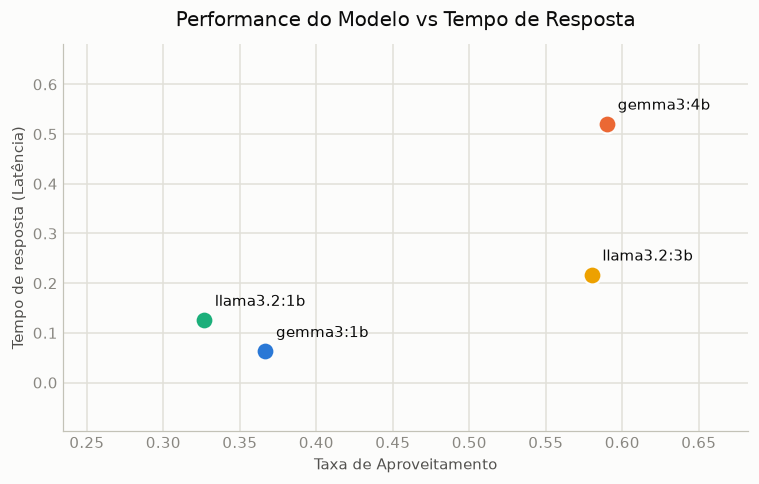

In [143]:
fig, ax = plt.subplots(figsize=(7, 4.5), dpi=110, facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")

# Reuses MODEL_COLORS from the score bar chart above, so each model keeps the
# same color everywhere in the notebook.
for model in scores.index:
    ax.scatter(
        scores[model], latency[model],
        s=140, color=MODEL_COLORS[model], zorder=3,
        edgecolors="#fcfcfb", linewidths=1.5,
    )
    ax.annotate(
        model, (scores[model], latency[model]),
        xytext=(7, 7), textcoords="offset points",
        fontsize=10, color="#0b0b0b", va="bottom",
    )

x_pad = (scores.max() - scores.min()) * 0.35 or 0.05
y_pad = (latency.max() - latency.min()) * 0.35 or 0.05
ax.set_xlim(scores.min() - x_pad, scores.max() + x_pad)
ax.set_ylim(latency.min() - y_pad, latency.max() + y_pad)

ax.grid(True, color="#e1e0d9", linewidth=1, zorder=0)
ax.set_axisbelow(True)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
for spine in ("left", "bottom"):
    ax.spines[spine].set_color("#c3c2b7")
ax.tick_params(colors="#898781", length=0)

ax.set_title("Performance do Modelo vs Tempo de Resposta", fontsize=13, color="#0b0b0b", pad=12)
ax.set_xlabel("Taxa de Aproveitamento", fontsize=10, color="#52514e")
ax.set_ylabel("Tempo de resposta (Latência)", fontsize=10, color="#52514e")

plt.tight_layout()
fig.savefig("./figures/score_vs_latency.png", dpi=300, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()